<a href="https://colab.research.google.com/github/sakshiiiii26/Amazon_Sales_Analysis/blob/main/Amazon_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **amazon sales analysis**

**loading dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
data = pd.read_csv("/content/Amazon Sale Report.csv")

In [ ]:
data

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN,NaN,NaN
128972,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,...,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN,NaN,NaN
128973,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,...,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN,NaN,NaN
128974,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,...,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN,NaN,NaN


**Taking insight of null values**

In [ ]:
data.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


# **Processing and Cleaning**

In [ ]:
data["ship-country"].unique()
data =  data.drop("ship-country", axis = 1)
data =  data.drop("currency", axis = 1)

In [ ]:
data =  data.drop("Courier Status", axis = 1)

In [ ]:
data = data.drop('fulfilled-by', axis=1)
data = data.drop('New',axis=1)
data = data.drop('PendingS', axis=1)

In [ ]:
data = data.drop('index', axis=1)


In [ ]:
data

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,0,647.62,MUMBAI,MAHARASHTRA,400081.0,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,1,406.00,BENGALURU,KARNATAKA,560085.0,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,1,574.00,CHENNAI,TAMIL NADU,600073.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,1,517.00,HYDERABAD,TELANGANA,500013.0,False
128972,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,1,999.00,GURUGRAM,HARYANA,122004.0,False
128973,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,1,690.00,HYDERABAD,TELANGANA,500049.0,False
128974,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,1,1199.00,Halol,Gujarat,389350.0,False


In [ ]:
data["Sales Channel"].unique()

array(['Amazon.in', 'Non-Amazon'], dtype=object)

# **EDA**

In [ ]:
df = data.copy()

In [ ]:
df.describe()

,Qty,Amount,ship-postal-code
count,128976.000000,121176.000000,128941.000000
mean,0.904401,648.562176,463945.677744
std,0.313368,281.185041,191458.488954
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [ ]:
df["Date"].unique()

array(['04-30-22', '04-29-22', '04-28-22', '04-27-22', '04-26-22',
       '04-25-22', '04-24-22', '04-23-22', '04-22-22', '04-21-22',
       '04-20-22', '04-19-22', '04-18-22', '04-17-22', '04-16-22',
       '04-15-22', '04-14-22', '04-13-22', '04-12-2022', '04-11-2022',
       '04-10-2022', '04-09-2022', '04-08-2022', '04-07-2022',
       '04-06-2022', '04-05-2022', '04-04-2022', '04-03-2022',
       '04-02-2022', '04-01-2022', '03-31-22', '05-31-22', '05-30-22',
       '05-29-22', '05-28-22', '05-27-22', '05-26-22', '05-25-22',
       '05-24-22', '05-23-22', '05-22-22', '05-21-22', '05-20-22',
       '05-19-22', '05-18-22', '05-17-22', '05-16-22', '05-15-22',
       '05-14-22', '05-13-22', '05-12-2022', '05-11-2022', '05-10-2022',
       '05-09-2022', '05-08-2022', '05-07-2022', '05-06-2022',
       '05-05-2022', '05-04-2022', '05-03-2022', '05-02-2022',
       '05-01-2022', '06-29-22', '06-28-22', '06-27-22', '06-26-22',
       '06-25-22', '06-24-22', '06-23-22', '06-22-22', '06-21-

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

<ipython-input-61-4ac1f8d99197>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


# Sales Trend

In [ ]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

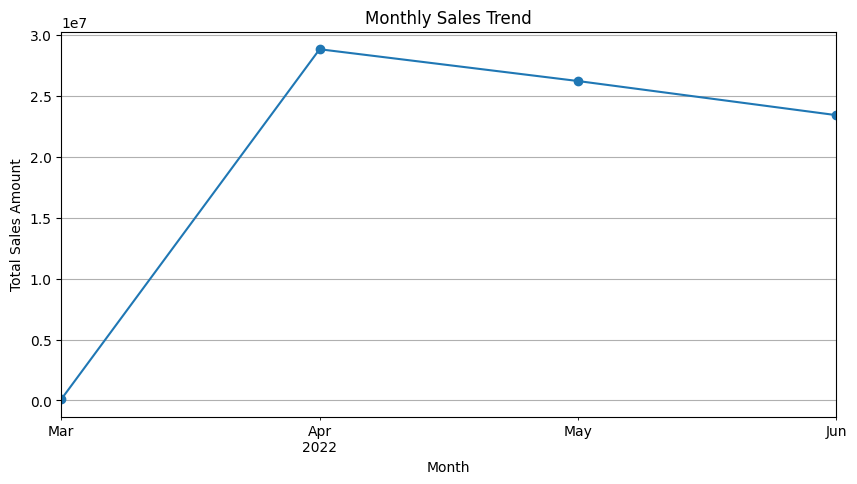

In [ ]:
monthly_sales.plot(kind='line', marker='o', figsize=(10, 5), title="Monthly Sales Trend")
plt.ylabel('Total Sales Amount')
plt.xlabel('Month')
plt.grid(True)
plt.show()

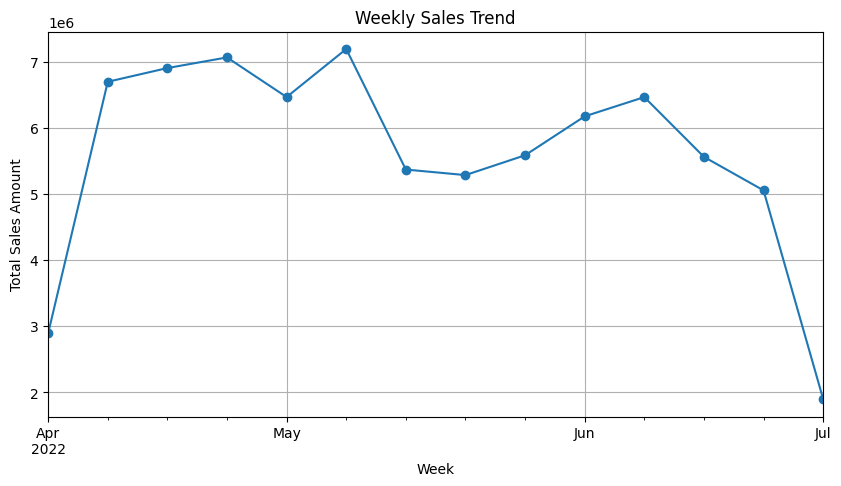

In [ ]:
Weekly_sales = df.groupby(df['Date'].dt.to_period('W'))['Amount'].sum()
Weekly_sales.plot(kind='line', marker='o', figsize=(10, 5), title="Weekly Sales Trend")
plt.ylabel('Total Sales Amount')
plt.xlabel('Week')
plt.grid(True)
plt.show()

# **Sales Overview Analysis**
Total Sales, Total Orders, Average Order Value

In [ ]:
total_sales = df['Amount'].sum()
total_sales

np.float64(78590170.24999997)

In [ ]:
total_orders = df['Order ID'].nunique()
total_orders

120229

In [ ]:
average_order_value = total_sales / total_orders
average_order_value = pd.DataFrame([average_order_value], columns=['Average Order Value'])
average_order_value

,Average Order Value
0,653.670664


In [ ]:
# average_order_value.to_csv('average_order_value.csv', index=False)
# files.download('average_order_value.csv')

# **Product Analysis**
Top Selling Categories

In [ ]:
Top_products = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)
Top_products

,Qty
Category,
T-shirt,45292
Shirt,45044
Blazzer,13943
Trousers,9898
Perfume,1051
Wallet,863
Socks,399
Shoes,153
Watch,3


In [ ]:
# Top_products.to_csv('Top_products by Qty.csv', index=False)
# files.download('Top_products by Qty.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

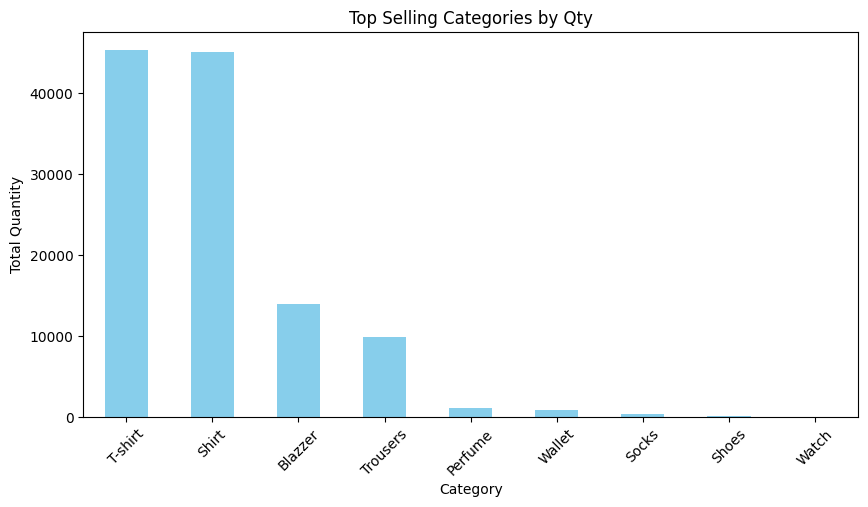

In [ ]:
Top_products.plot(kind='bar', title="Top Selling Categories by Qty", figsize=(10,5), color='skyblue')
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Demanding_Size = df.groupby('Size')['Qty'].sum().sort_values(ascending=False)
Demanding_Size

,Qty
Size,
M,20138
L,19706
XL,18636
XXL,16246
S,15041
3XL,13360
XS,9850
Free,2070
6XL,688


In [ ]:
# Demanding_Size.to_csv('Demanding_Size.csv', index=False)
# files.download('Demanding_Size.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

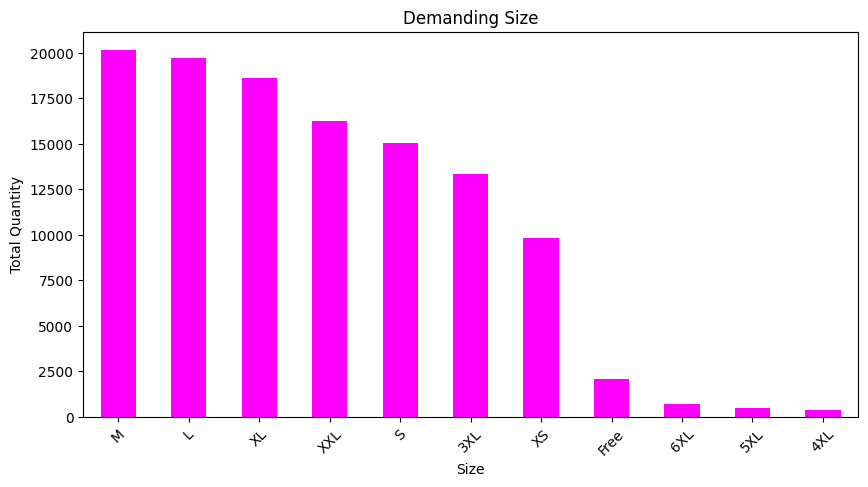

In [ ]:
Demanding_Size.plot(kind='bar', title="Demanding Size", figsize=(10,5), color='magenta')
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_categories = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
top_categories

,Amount
Category,
T-shirt,39206756.65
Shirt,21297770.08
Blazzer,11215104.12
Trousers,5346286.30
Perfume,789419.66
Wallet,458408.18
Socks,150757.50
Shoes,124752.76
Watch,915.00


In [ ]:
# top_categories.to_csv('Top_products by Sales.csv', index=False)
# files.download('Top_products by Sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

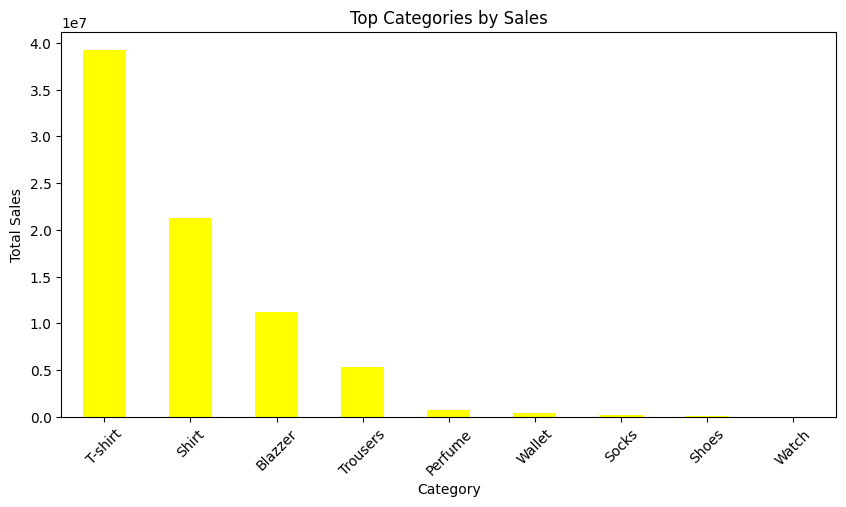

In [ ]:
top_categories.plot(kind='bar', title="Top Categories by Sales", figsize=(10,5), color='yellow')
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# **Fulfillment Analysis**
Orders by Fulfillment Type

In [ ]:
Fulfilment = df.groupby('Fulfilment').size().sort_values(ascending=False)
# Fulfilment.to_csv('Fulfilment.csv', index=False)
# files.download('Fulfilment.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

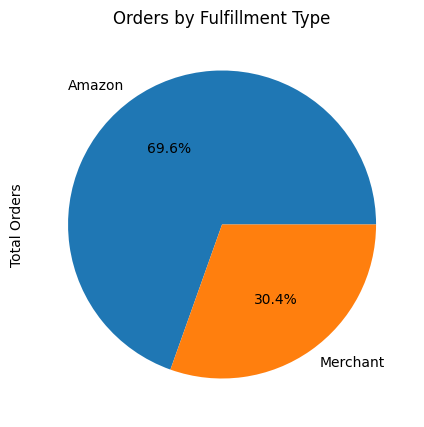

In [ ]:
Fulfilment.plot(kind='pie', title="Orders by Fulfillment Type",autopct='%1.1f%%', figsize=(10,5))
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Fulfilment'].value_counts(normalize=True) * 100

,proportion
Fulfilment,
Amazon,69.557902
Merchant,30.442098


In [ ]:
cancelled_orders = df[df['Status'] == 'Cancelled']
cancelled_orders_rate = cancelled_orders.groupby('Fulfilment').size().sort_values(ascending=False)

In [ ]:
# cancelled_orders_rate.to_csv('cancelled_orders_rate.csv', index=False)
# files.download('cancelled_orders_rate.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

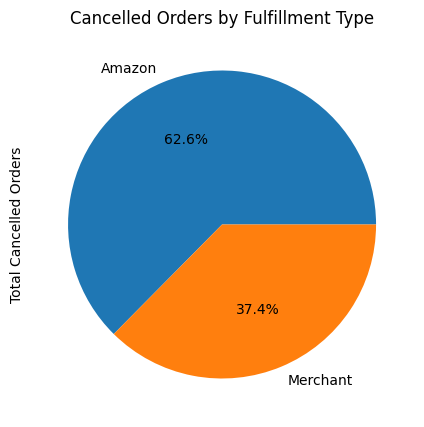

In [ ]:
cancelled_orders_rate.plot(kind='pie', title="Cancelled Orders by Fulfillment Type",autopct='%1.1f%%', figsize=(10,5))
plt.ylabel("Total Cancelled Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
recieved_orders = df[(df['Status'] == 'Shipped') | (df['Status'] == 'Shipped - Delivered to Buyer')]
recieved_orders_rate = recieved_orders.groupby('Fulfilment').size().sort_values(ascending=False)

In [ ]:
# recieved_orders_rate.to_csv('recieved_orders_rate.csv', index=False)
# files.download('recieved_orders_rate.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

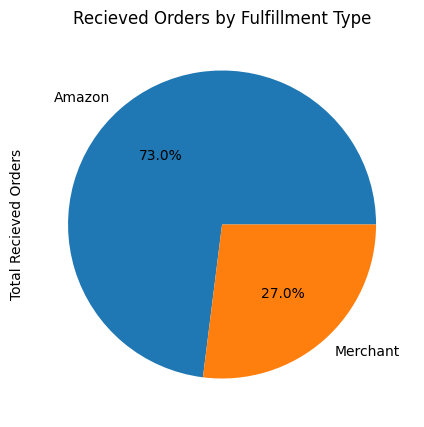

In [ ]:
recieved_orders_rate.plot(kind='pie', title="Recieved Orders by Fulfillment Type", autopct='%1.1f%%',figsize=(10,5))
plt.ylabel("Total Recieved Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head(10)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,0,647.62,MUMBAI,MAHARASHTRA,400081.0,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,1,406.00,BENGALURU,KARNATAKA,560085.0,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,1,574.00,CHENNAI,TAMIL NADU,600073.0,False
5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XL,1,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,False
6,408-5748499-6859555,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,L,1,653.00,CHANDIGARH,CHANDIGARH,160036.0,False
7,406-7807733-3785945,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,S,1,399.00,HYDERABAD,TELANGANA,500032.0,False
8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,0,NaN,HYDERABAD,TELANGANA,500008.0,False
9,402-4393761-0311520,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XXL,1,363.00,Chennai,TAMIL NADU,600041.0,False


# **customer segmentation**
cluster by region


In [ ]:
state_count = df.groupby('ship-state')['Order ID'].count().sort_values(ascending=False)
State10order = state_count.head(10)
State10order

,Order ID
ship-state,
MAHARASHTRA,22272
KARNATAKA,17324
TAMIL NADU,11488
TELANGANA,11330
UTTAR PRADESH,10646
DELHI,6778
KERALA,6577
WEST BENGAL,5962
ANDHRA PRADESH,5427


In [ ]:
# state_count.to_csv('state_count.csv', index=False)
# files.download('state_count.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

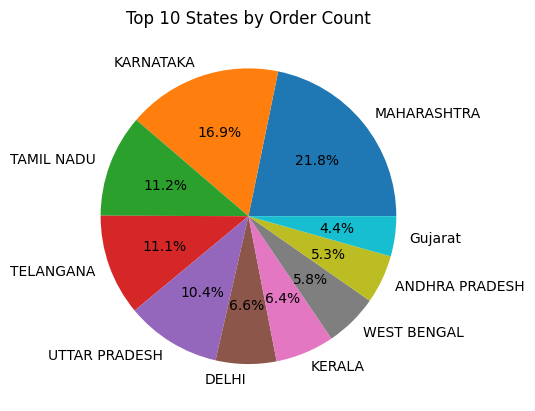

In [ ]:
plt.pie(State10order, labels=State10order.index, autopct='%1.1f%%')
plt.title('Top 10 States by Order Count')
plt.xticks(rotation=90)
plt.show()

**High value customer**

In [ ]:
low_valued_customer = df[df['Amount'] < 800].sort_values(by='Amount', ascending=True)
top20 = low_valued_customer.head(20)
top20

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
73245,408-0738129-6851528,2022-05-12,Shipped,Amazon,Amazon.in,Standard,Shirt,L,1,0.0,KOCHI,KERALA,682006.0,False
25804,408-8522544-2305139,2022-04-15,Shipped,Amazon,Amazon.in,Standard,Shirt,XXL,1,0.0,CHENNAI,TAMIL NADU,600100.0,False
117967,408-2414115-5924327,2022-06-08,Shipped,Amazon,Amazon.in,Standard,T-shirt,XL,1,0.0,Salem,TAMIL NADU,636005.0,False
73336,408-1403038-2692327,2022-05-12,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,3XL,1,0.0,KOTA,RAJASTHAN,324009.0,False
2296,408-8447246-2180344,2022-04-29,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,1,0.0,CHANDIGAR,CHANDIGARH,160022.0,False
99770,408-3586716-5893950,2022-06-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Blazzer,M,1,0.0,BENGALURU,KARNATAKA,560087.0,False
47797,408-9013326-1123502,2022-04-01,Shipped,Amazon,Amazon.in,Standard,Shirt,L,1,0.0,CHENNAI,TAMIL NADU,600042.0,False
73243,408-1175509-3683523,2022-05-12,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,L,1,0.0,KOCHI,KERALA,682006.0,False
25572,408-1498643-7327558,2022-04-15,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,XL,1,0.0,NAVI MUMBAI,MAHARASHTRA,400703.0,False
25578,408-9287075-3373928,2022-04-15,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,1,0.0,AGRA,UTTAR PRADESH,282007.0,False


In [ ]:
# low_valued_customer.to_csv('low_valued_customer.csv', index=False)
# files.download('low_valued_customer.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

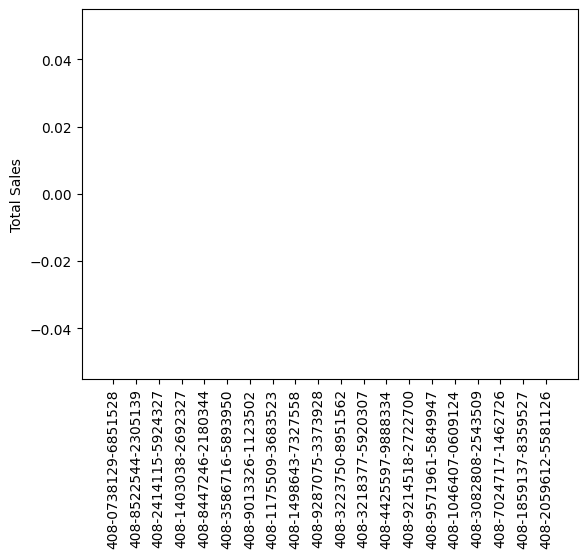

In [ ]:
plt.bar(top20['Order ID'], top20['Amount'])
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

In [ ]:
high_valued_customer = df[df['Amount'] > 2000]
high_valued_customer

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
266,171-6655820-6440356,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XXL,2,2130.00,MUMBAI,MAHARASHTRA,400101.0,False
648,171-6153595-4758722,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,2,2224.00,VASAI VIRAR,MAHARASHTRA,401209.0,False
3290,406-3338330-9401954,2022-04-28,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Blazzer,M,3,2175.00,KANPUR,UTTAR PRADESH,208001.0,False
11161,403-4106553-1691525,2022-04-23,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,3XL,5,5495.00,JALANDHAR,PUNJAB,144022.0,True
13699,403-3943362-8896346,2022-04-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,3XL,2,2198.00,JALANDHAR,PUNJAB,144022.0,True
16578,405-4362525-1025138,2022-04-20,Shipped,Amazon,Amazon.in,Expedited,T-shirt,3XL,1,2299.00,JAMMU,JAMMU & KASHMIR,180012.0,False
17280,404-1362203-3716347,2022-04-20,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,2,2224.00,HISAR,HARYANA,125001.0,False
17287,404-9390368-1493927,2022-04-20,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,M,2,2224.00,HISAR,HARYANA,125001.0,False
20535,406-1124784-1093950,2022-04-18,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Blazzer,M,3,2232.00,Kochi,KERALA,682036.0,False
24495,407-3483041-9133135,2022-04-16,Cancelled,Merchant,Amazon.in,Standard,T-shirt,M,0,4235.72,Jaipur,RAJASTHAN,302012.0,False


In [ ]:
# high_valued_customer.to_csv('high_valued_customer.csv', index=False)
# files.download('high_valued_customer.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

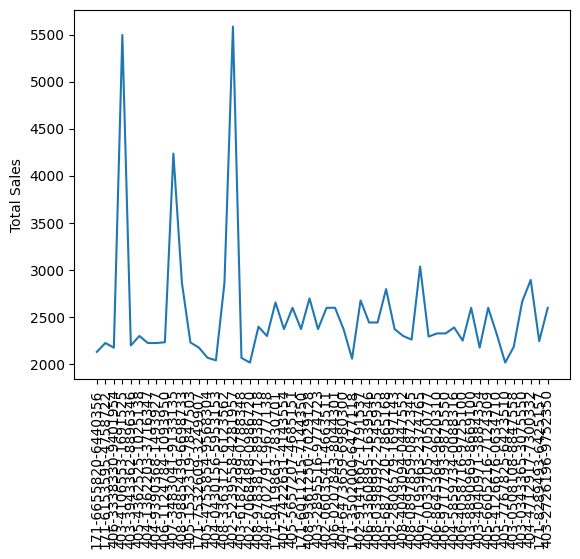

In [ ]:
plt.plot(high_valued_customer['Order ID'], high_valued_customer['Amount'])
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

In [ ]:
avg_customer_value = df[(df['Amount'] > 800) & (df['Amount'] < 2000)]
avg20 = avg_customer_value.head(20)
avg20

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B
5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XL,1,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,False
19,405-5957858-1051546,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,1,886.00,BENGALURU,KARNATAKA,560017.0,False
32,404-9632124-1107550,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,M,1,1233.00,VISAKHAPATNAM,ANDHRA PRADESH,530016.0,False
41,402-8210765-3935569,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Blazzer,3XL,1,885.00,JABALPUR,MADHYA PRADESH,482002.0,False
43,408-3478480-0881162,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,1,1126.00,LUCKNOW,UTTAR PRADESH,226017.0,False
46,408-3917043-5314763,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,L,1,1146.00,ONGOLE,ANDHRA PRADESH,523001.0,False
50,408-2137113-0982751,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,1,848.00,CUTTACK,ODISHA,753012.0,False
52,408-7138000-9728362,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,1,1033.00,dimapur,NAGALAND,797112.0,False
58,406-8089333-7941903,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,S,1,888.00,Bengaluru,KARNATAKA,560103.0,False
63,405-3594372-1614709,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,1,852.00,GREATER NOIDA,UTTAR PRADESH,201306.0,False


In [ ]:
# avg_customer_value.to_csv('avg_customer_value.csv', index=False)
# files.download('avg_customer_value.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

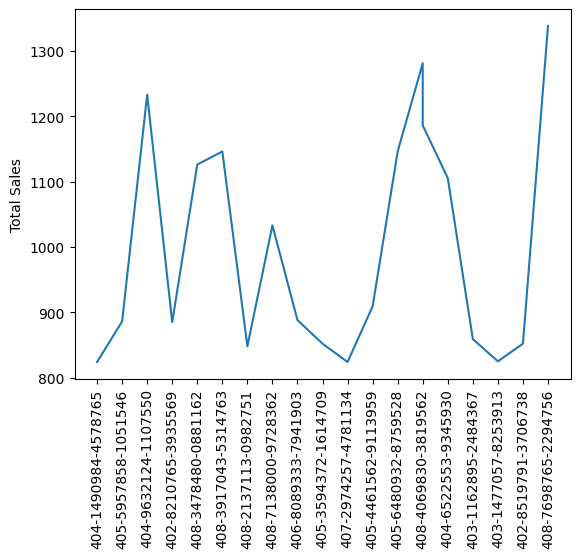

In [ ]:
plt.plot(avg20['Order ID'], avg20['Amount'])
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

# **Geographical Sales Analysis**
Total Sales by State & City

In [ ]:
state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)
city_sales = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False)
print("Top 10 States by Sales:\n", state_sales.head(10))
print("Top 10 Cities by Sales:\n", city_sales.head(10))

Top 10 States by Sales:
 ship-state
MAHARASHTRA       13340333.05
KARNATAKA         10480694.22
TELANGANA          6915018.08
UTTAR PRADESH      6823947.08
TAMIL NADU         6519182.30
DELHI              4232738.97
KERALA             3823559.58
WEST BENGAL        3507212.82
ANDHRA PRADESH     3217859.86
HARYANA            2880355.99
Name: Amount, dtype: float64
Top 10 Cities by Sales:
 ship-city
BENGALURU    6845390.65
HYDERABAD    4946394.25
MUMBAI       3701843.04
NEW DELHI    3612512.78
CHENNAI      3103415.74
PUNE         2342011.18
KOLKATA      1413603.87
GURUGRAM     1220562.74
THANE        1004503.29
LUCKNOW       938076.34
Name: Amount, dtype: float64


In [ ]:
state_sales.to_csv('state_sales.csv', index=False)
files.download('state_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# city_sales.to_csv('city_sales.csv', index=False)
# files.download('city_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

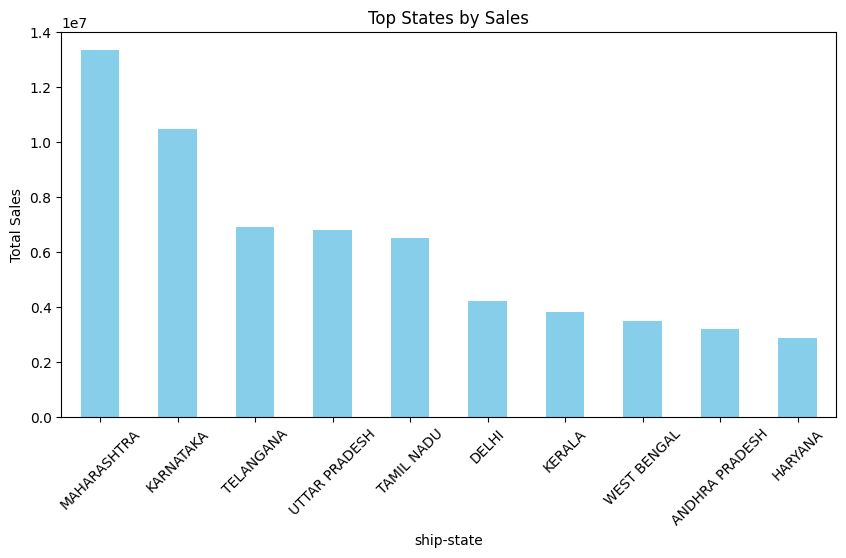

In [ ]:
state_sales.head(10).plot(kind='bar', title="Top States by Sales", figsize=(10,5), color='skyblue')
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


Cancelled rates pr region

In [ ]:
total_orders = df.groupby('ship-state')['Order ID'].count()
cancelled_orders = df[df['Status'] == 'Cancelled'].groupby('ship-state')['Order ID'].count()
cancel_rate = (cancelled_orders / total_orders).fillna(0) * 100
cancel_rate = cancel_rate.sort_values(ascending=False)
print("Top States by Return Rate:\n", cancel_rate.head(10))

Top States by Return Rate:
 ship-state
APO                  100.000000
Meghalaya            100.000000
Arunachal Pradesh     33.333333
Rajshthan             33.333333
LAKSHADWEEP           25.000000
Odisha                23.809524
MIZORAM               18.666667
HIMACHAL PRADESH      18.504436
KERALA                17.850084
ANDAMAN & NICOBAR     17.578125
Name: Order ID, dtype: float64


In [ ]:
# cancel_rate.to_csv('cancel_rate.csv', index=False)
# files.download('cancel_rate.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

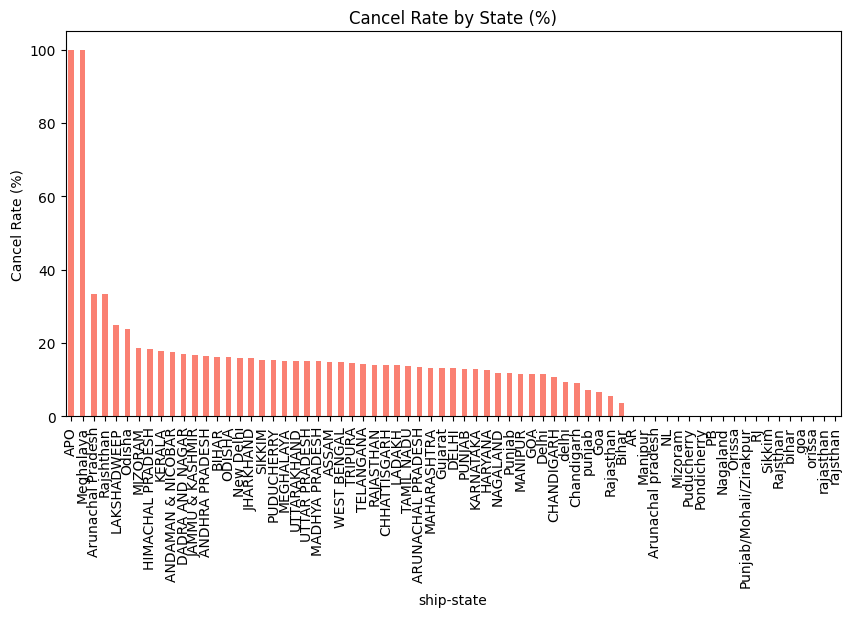

In [ ]:
cancel_rate.plot(kind='bar',title="Cancel Rate by State (%)", color='salmon', figsize=(10,5))
plt.ylabel("Cancel Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# df.to_csv('cleaned_amazon_sales.csv', index=False)
# files.download('cleaned_amazon_sales.csv')
